<a id='abs'></a>
# Forecasting HDFC Bank Volatility: GARCH vs. XGBoost

**Author:** Udit Chauhan

This notebook compares a classical econometric approach (GARCH) against a modern gradient-boosted tree model (XGBoost) for forecasting stock volatility, using **HDFC Bank Limited** (NSE: HDFCBANK) as the case study.

Volatility forecasting is central to option pricing, portfolio risk management, and position sizing. Here we fit a GARCH model directly to the return series and separately train an XGBoost regressor on calendar and lagged-volatility features, then measure how well each one anticipates the stock's realised monthly volatility on data neither model has seen. The results suggest that the tree-based model edges out the classical GARCH specification on this particular series, echoing similar findings reported for other single-stock volatility studies, while also being a reminder that no single tool is guaranteed to win across every market regime.

**About HDFC Bank:** HDFC Bank is one of India's largest private-sector banks, offering retail and wholesale banking, treasury operations, and a wide range of financial products across the country. As a large, liquid, frequently-traded banking stock, it makes a good subject for a volatility-modelling exercise.

**Dataset window:** the trailing ~15 years of daily OHLCV data for HDFCBANK.NS, pulled live from Yahoo Finance via `yfinance` every time this notebook runs — so the exact date range and the very last row shift forward each time you re-run it.

**Training period:** everything except the most recent 251 trading days.

**Test period (out-of-sample, never seen by either model during fitting):** the most recent 251 trading days available at run time.

Forecasts are produced on a rolling basis, one trading day at a time, and evaluated against a **22-day rolling realised volatility** benchmark (roughly one trading month).

**Models used:**

The GARCH family models the conditional variance of returns as a function of past shocks and past variances. The (4,4) specification with a generalized error distribution used here is:

$$ \sigma_t^2 = \omega + \sum_{i=1}^{4}\alpha_i \epsilon_{t-i}^2 + \sum_{j=1}^{4}\beta_j \sigma_{t-j}^2 $$

XGBoost, on the other hand, makes no distributional assumptions about returns. It is a gradient-boosted ensemble of decision trees that we feed with calendar features (day of week, month, quarter, etc.) plus the last four days of rolling volatility, letting it learn any nonlinear or seasonal patterns in volatility on its own.

### Contents

1. [Introduction](#abs)
2. [Library Setup](#imp)
3. [Loading & Cleaning HDFC Bank Data](#rea)
4. [Exploratory Analysis: Returns & Volatility](#eda)
5. [Modelling: GARCH(4,4) vs. XGBoost](#gar)
6. [Results & Comparison](#res)


<a id='imp'></a>
## 1. Library Setup

In [1]:
import math
import datetime
import warnings

import numpy as np
import pandas as pd

import plotly.express as px
import plotly.figure_factory as ff
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from xgboost import plot_importance, plot_tree

import yfinance as yf

from arch import arch_model
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from tabulate import tabulate
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

# Plot styling
plt.style.use('fivethirtyeight')

# Keep the output readable
warnings.filterwarnings('ignore')

<a id='rea'></a>
## 2. Loading & Cleaning HDFC Bank Data

**Source:** Daily OHLCV price history for **HDFCBANK.NS**, pulled live from Yahoo Finance through the `yfinance` package rather than a saved CSV — so every time this notebook is executed it fetches the latest ~15 years of trading data available at that moment, and the analysis below always reflects the most current prices.

`yfinance` can occasionally hand back a `MultiIndex` column layout even for a single ticker, so we flatten that if it happens and standardise on a plain `Date` column plus `Open/High/Low/Close/Adj Close/Volume`. From here on we work only with the **`Close`** column.

Daily return is computed as the simple percentage change between two consecutive closes:

$$ \text{Return}_t = \left(\frac{P_t}{P_{t-1}} - 1\right) \times 100\% $$

In [2]:
# Pull ~15 years of HDFC Bank daily price history live from Yahoo Finance.
TICKER = "HDFCBANK.NS"
LOOKBACK_YEARS = 15

end_date = datetime.date.today()
start_date = end_date - datetime.timedelta(days=365 * LOOKBACK_YEARS)

hdfc_raw = yf.download(TICKER, start=start_date, end=end_date, auto_adjust=False, progress=False)

# yfinance sometimes returns a MultiIndex on the columns (Price, Ticker) even for a single symbol — flatten it if so
if isinstance(hdfc_raw.columns, pd.MultiIndex):
    hdfc_raw.columns = hdfc_raw.columns.get_level_values(0)

hdfc_raw = hdfc_raw.reset_index()  # turns the DatetimeIndex into a 'Date' column
hdfc_raw = hdfc_raw.sort_values("Date").reset_index(drop=True)

print(f"Downloaded {len(hdfc_raw)} trading days: {hdfc_raw['Date'].min().date()} to {hdfc_raw['Date'].max().date()}")

# Daily % return, computed from the Close price
returns_hdfc = 100 * hdfc_raw["Close"].pct_change().dropna()
returns_hdfc.index = hdfc_raw["Date"].iloc[1:]

# A handful of rows can come through as an exact 0% return (public holidays / data gaps); drop those
returns_hdfc = returns_hdfc.drop(returns_hdfc[returns_hdfc == 0].index)

returns_hdfc.head(3)

Downloaded 3696 trading days: 2011-08-29 to 2026-08-21


Date
2011-08-30    3.395772
2011-09-02    0.180099
2011-09-05   -0.539338
Name: Close, dtype: float64

<a id='eda'></a>
## 3. Exploratory Analysis: Returns & Volatility

The cleaned series gives us daily returns for HDFC Bank spanning the full ~15-year window above. Before touching either model, it's worth looking at the shape of the returns and how volatility clusters over time.

In [3]:
# Average daily return
returns_hdfc.mean()

np.float64(0.06067618968602159)

The mean daily return is small and noisy on its own — as expected for a large-cap bank stock — so for this notebook we set the *level* of returns aside and focus entirely on their *dispersion*, i.e. volatility.

In [4]:
# Plot the cumulative growth of HDFC Bank's share price over the sample
close_prices = pd.DataFrame(hdfc_raw.set_index("Date")["Close"])
cum_rets = close_prices / close_prices.iloc[0, :]

start_label = hdfc_raw["Date"].min().strftime("%Y-%m-%d")
end_label = hdfc_raw["Date"].max().strftime("%Y-%m-%d")

fig = px.line(cum_rets, width=1000, height=500)
fig.update_layout(title_text=f"HDFC Bank — Cumulative Price Growth ({start_label} to {end_label})")
fig.show()

### 3.1 Measuring Volatility

In [5]:
# Daily volatility = standard deviation of daily returns
daily_volatility = returns_hdfc.std()

# Scale up to monthly (~21 trading days) and annual (~252 trading days) volatility
monthly_volatility = math.sqrt(21) * daily_volatility
annual_volatility = math.sqrt(252) * daily_volatility

print(tabulate(
    [["HDFC Bank", daily_volatility, monthly_volatility, annual_volatility]],
    headers=["Daily Volatility %", "Monthly Volatility %", "Annual Volatility %"],
    tablefmt="fancy_grid", stralign="center", numalign="center", floatfmt=".2f"
))

╒═══════════╤══════════════════════╤════════════════════════╤═══════════════════════╕
│           │  Daily Volatility %  │  Monthly Volatility %  │  Annual Volatility %  │
╞═══════════╪══════════════════════╪════════════════════════╪═══════════════════════╡
│ HDFC Bank │         1.44         │          6.60          │         22.85         │
╘═══════════╧══════════════════════╧════════════════════════╧═══════════════════════╛


Daily returns, plotted directly:

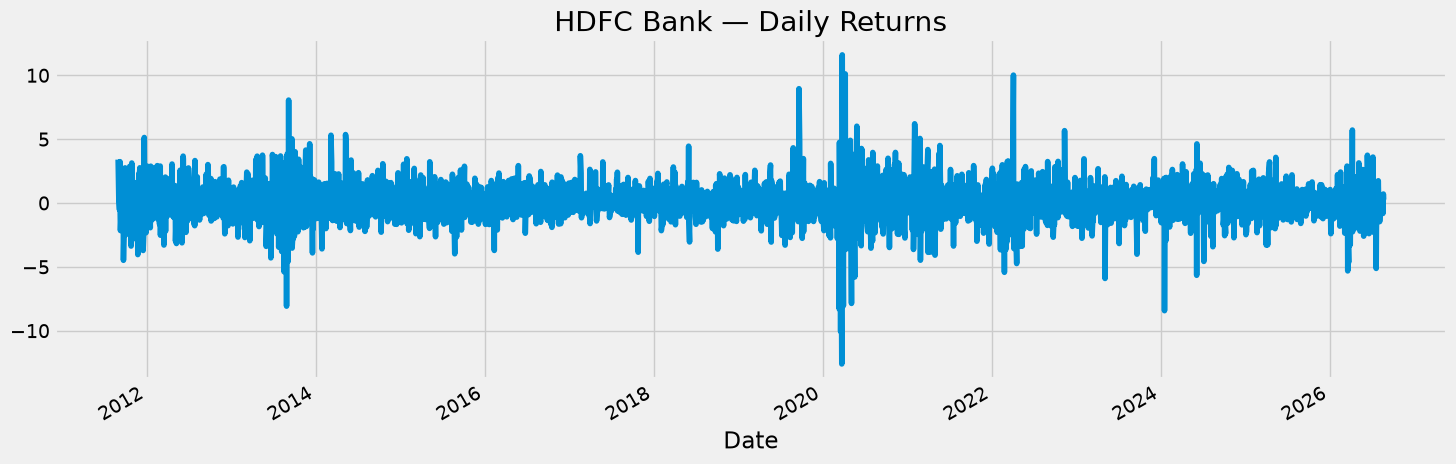

In [6]:
returns_hdfc.plot(figsize=(16, 5), title="HDFC Bank — Daily Returns");

In [7]:
# Distribution of daily returns
return_dist_plot = ff.create_distplot([returns_hdfc.values.reshape(-1)], group_labels=[' '])
return_dist_plot.update_layout(showlegend=False, title_text="Distribution of HDFC Bank Daily Returns", width=1000, height=500)
return_dist_plot.show()

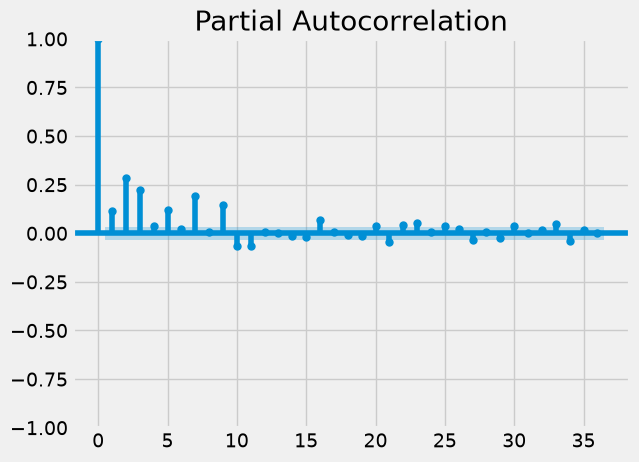

In [8]:
# Partial autocorrelation of squared returns — a standard diagnostic for volatility clustering / ARCH effects
plot_pacf(returns_hdfc**2, method="yw")
plt.show()

The PACF of squared returns stays meaningfully positive well beyond lag 1, which is the classic signature of volatility clustering: large moves tend to be followed by more large moves. That's exactly the pattern a GARCH model is designed to capture, and it's also why feeding recent volatility back into the XGBoost model as a feature should help.

<a id='gar'></a>
## 4. Modelling: GARCH(4,4) vs. XGBoost

### 4.1 GARCH(4,4)

In [9]:
# GARCH(4,4) with a generalized error distribution (ged) — chosen to accommodate the fatter tails typical of equity returns
model = arch_model(returns_hdfc, dist="ged", vol="GARCH", p=4, q=4)
model_fit = model.fit(disp="off")
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Constant Mean - GARCH Model Results                            
==========================================================================================
Dep. Variable:                              Close   R-squared:                       0.000
Mean Model:                         Constant Mean   Adj. R-squared:                  0.000
Vol Model:                                  GARCH   Log-Likelihood:               -6055.93
Distribution:      Generalized Error Distribution   AIC:                           12133.9
Method:                        Maximum Likelihood   BIC:                           12202.2
                                                    No. Observations:                 3681
Date:                            Mon, Aug 24 2026   Df Residuals:                     3680
Time:                                    00:52:46   Df Model:                            1
                                 Mean Model                                 
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0507  1.152e-02      4.399  1.090e-05 [2.809e-02,7.325e-02]
                               Volatility Model                              
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega          0.0599  4.340e-02      1.381      0.167   [-2.513e-02,  0.145]
alpha[1]       0.0987  1.759e-02      5.613  1.989e-08    [6.424e-02,  0.133]
alpha[2]   1.2860e-05  4.632e-02  2.776e-04      1.000 [-9.077e-02,9.080e-02]
alpha[3]   3.0391e-06  5.741e-02  5.294e-05      1.000      [ -0.113,  0.113]
alpha[4]   1.3908e-07  6.817e-02  2.040e-06      1.000      [ -0.134,  0.134]
beta[1]        0.6136      0.676      0.908      0.364      [ -0.711,  1.938]
beta[2]    8.7350e-05      1.050  8.316e-05      1.000      [ -2.059,  2.059]
beta[3]    3.1216e-06      0.914  3.414e-06      1.000      [ -1.792,  1.792]
beta[4]        0.2545      0.476      0.535      0.593      [ -0.678,  1.187]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             1.2904  5.122e-02     25.192 4.931e-140 [  1.190,  1.391]
========================================================================

Covariance estimator: robust
"""

In [10]:
# Fit the same specification on the full series and compare its fitted conditional volatility to realised (rolling) volatility
full_serie_garch = arch_model(returns_hdfc, dist="ged", vol="GARCH", p=4, q=4)
model_fit_full_serie = full_serie_garch.fit(disp="off")

rolling_vol = abs(returns_hdfc.rolling(window=22, min_periods=22).std().dropna())

garch_and_rolling_std = pd.concat(
    [pd.DataFrame(model_fit_full_serie.conditional_volatility), rolling_vol.dropna()], axis=1
).dropna()

garch_fit_plot = px.line(garch_and_rolling_std, title="GARCH Conditional Volatility vs. 22-Day Rolling Volatility — In-Sample", width=1000, height=500)
garch_fit_plot.show()

In [11]:
# Rolling one-step-ahead forecast: refit the model each day on everything up to that point, then forecast the next day's volatility
test_size = 251
rolling_predictions = []

for i in range(test_size):
    train = returns_hdfc[:-(test_size - i)]
    model = arch_model(train, dist="ged", vol="GARCH", p=4, q=4)
    model_fit = model.fit(disp="off")
    pred = model_fit.forecast(horizon=1, reindex=False)
    rolling_predictions.append(np.sqrt(pred.variance.values[-1, :][0]))

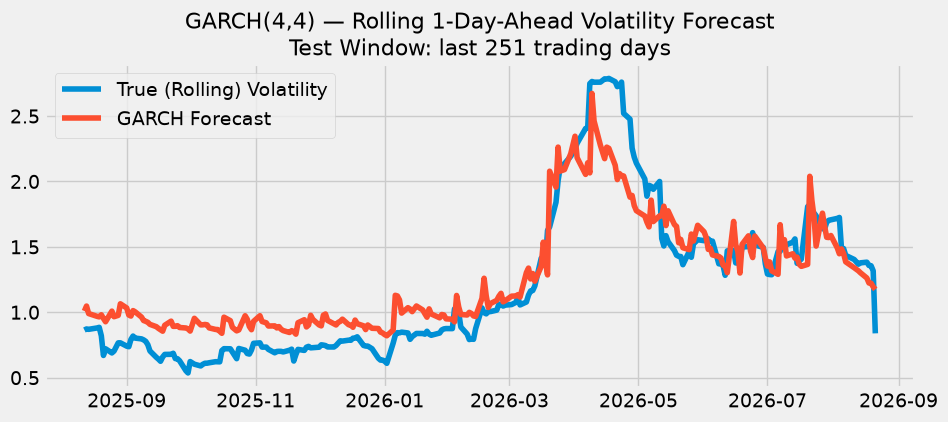

In [28]:
rolling_predictions = pd.Series(rolling_predictions, index=returns_hdfc.dropna().index[-test_size:])

plt.figure(figsize=(10, 4))
true, = plt.plot((rolling_vol)[-test_size:])
preds, = plt.plot(rolling_predictions)
plt.title(f"GARCH(4,4) — Rolling 1-Day-Ahead Volatility Forecast\nTest Window: last {test_size} trading days", fontsize=16)
plt.legend(['True (Rolling) Volatility', 'GARCH Forecast'], fontsize=14)
plt.show()

### 4.2 XGBoost

In [13]:
# Rebuild the return series from scratch, this time keeping Date alongside Close for feature engineering
hdfc_for_ml = hdfc_raw[["Date", "Close"]].copy()
hdfc_for_ml["Close"] = 100 * hdfc_raw["Close"].pct_change()
hdfc_for_ml = hdfc_for_ml.drop(hdfc_for_ml[hdfc_for_ml["Close"] == 0].index)
hdfc_for_ml = hdfc_for_ml.dropna()

# The target is the same 22-day rolling realised volatility used for GARCH, so both models are judged on a like-for-like basis
hdfc_for_ml["Close"] = abs(hdfc_for_ml["Close"].rolling(window=22, min_periods=22).std())

serie_for_xgboost = hdfc_for_ml
test_size = 251

train_ml = serie_for_xgboost[:-test_size].dropna()
test_ml = serie_for_xgboost[-test_size:].dropna()

In [14]:
def create_features(df, label=None):
    '''Build calendar-based features from the Date column.'''
    df['dayofweek'] = df['Date'].dt.dayofweek
    df['quarter'] = df['Date'].dt.quarter
    df['month'] = df['Date'].dt.month
    df['year'] = df['Date'].dt.year
    df['dayofyear'] = df['Date'].dt.dayofyear
    df['dayofmonth'] = df['Date'].dt.day

    X = df[['dayofweek', 'quarter', 'month', 'year', 'dayofyear', 'dayofmonth']]
    if label:
        y = df[label]
        return X, y
    return X

In [15]:
X_train, y_train = create_features(train_ml, label="Close")
X_test, y_test = create_features(test_ml, label="Close")

In [16]:
# Add the previous 4 days of rolling volatility as lagged features, giving the model an autoregressive signal to work with
X_train['prev1'] = train_ml['Close'].shift(1)
X_test['prev1'] = test_ml['Close'].shift(1)
X_train['prev2'] = train_ml['Close'].shift(2)
X_test['prev2'] = test_ml['Close'].shift(2)
X_train['prev3'] = train_ml['Close'].shift(3)
X_test['prev3'] = test_ml['Close'].shift(3)
X_train['prev4'] = train_ml['Close'].shift(4)
X_test['prev4'] = test_ml['Close'].shift(4)

In [17]:
reg = xgb.XGBRegressor(n_estimators=1000, early_stopping_rounds=50)
reg.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


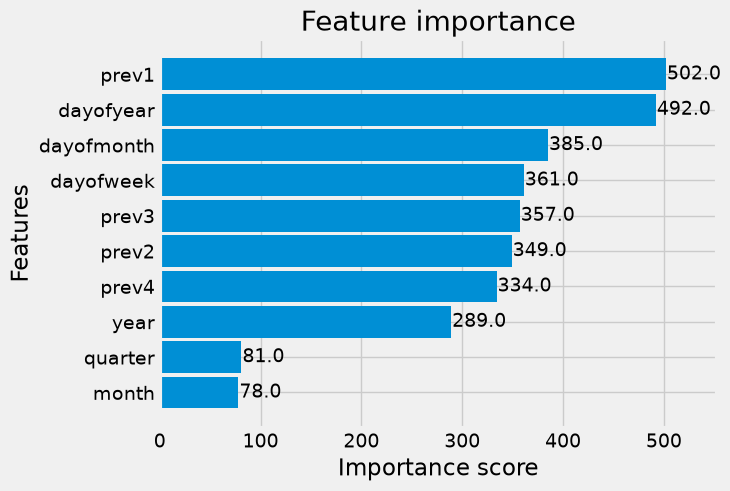

In [18]:
_ = plot_importance(reg, height=0.9)

In [19]:
train_ml["Predictions"] = reg.predict(X_train)
test_ml['Prediction'] = reg.predict(X_test)

In [20]:
XGBoost_and_rolling = pd.concat(
    [pd.DataFrame(list(train_ml["Predictions"]), list(train_ml["Close"]))], axis=1
).dropna().reset_index()
XGBoost_and_rolling.rename(columns={"index": "Real_Volatility", 0: "Predicted Volatility"}, inplace=True)
XGBoost_and_rolling.head(3)

,Real_Volatility,Predicted Volatility
0,1.977248,1.975898
1,1.910716,1.937902
2,1.933064,1.920400


In [21]:
XGBoost_and_rolling = pd.concat(
    [pd.DataFrame(list(train_ml["Predictions"]), list(train_ml["Close"]))], axis=1
).dropna().reset_index()
XGBoost_and_rolling.rename(columns={"index": "Real_Volatility", 0: "Predicted Volatility"}, inplace=True)

xgb_fit_plot = px.line(XGBoost_and_rolling, title="XGBoost Fitted Values vs. 22-Day Rolling Volatility — In-Sample", width=1000, height=500)
xgb_fit_plot.show()

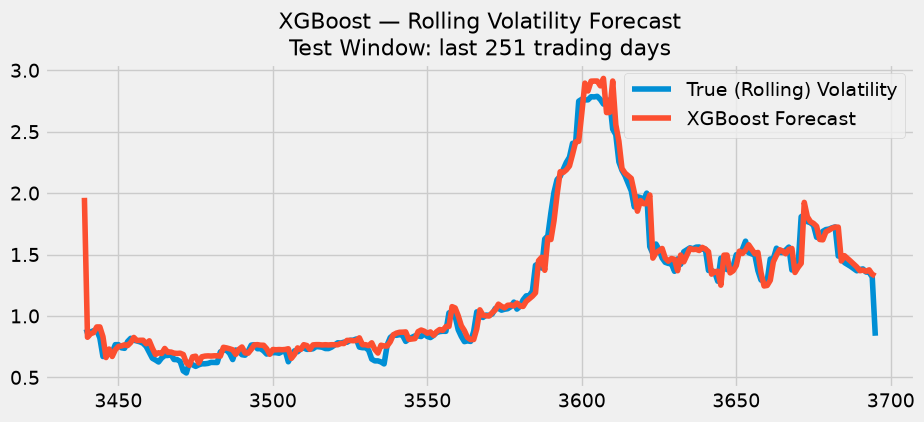

In [22]:
plt.figure(figsize=(10, 4))
true, = plt.plot(test_ml["Close"])
preds, = plt.plot(test_ml['Prediction'])
plt.title(f"XGBoost — Rolling Volatility Forecast\nTest Window: last {test_size} trading days", fontsize=16)
plt.legend(['True (Rolling) Volatility', 'XGBoost Forecast'], fontsize=14)

<a id='res'></a>
## 5. Results & Comparison

**Evaluation metrics**

*Root Mean Squared Error (RMSE)* — the square root of the average squared gap between predicted and actual volatility. It penalises large misses more heavily than small ones:

$$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

*Mean Absolute Percentage Error (MAPE)* — average absolute error expressed as a percentage of the true value, useful for comparing accuracy in relative rather than absolute terms:

$$\text{MAPE} = \frac{100}{n} \sum_{i=1}^{n} \frac{|A_i - F_i|}{|A_i|}$$

where $A_i$ is the actual value, $F_i$ is the forecast, and $n$ is the number of samples in the window being scored.

In [23]:
RMSE_Serie = mean_squared_error(garch_and_rolling_std["Close"], garch_and_rolling_std["cond_vol"]) ** 0.5
MAPE_Serie = mean_absolute_percentage_error(garch_and_rolling_std["Close"], garch_and_rolling_std["cond_vol"])
print(f"GARCH — in-sample RMSE: {round(RMSE_Serie, 4)}")
print(f"GARCH — in-sample MAPE: {round(MAPE_Serie * 100, 2)}%")

GARCH — in-sample RMSE: 0.2267
GARCH — in-sample MAPE: 13.99%


In [24]:
true_vol = rolling_vol[-test_size:]
pred_vol = rolling_predictions
RMSE = mean_squared_error(true_vol, pred_vol) ** 0.5
MAPE = mean_absolute_percentage_error(true_vol, pred_vol)
print(f"GARCH — out-of-sample RMSE: {round(RMSE, 4)}")
print(f"GARCH — out-of-sample MAPE: {round(MAPE * 100, 2)}%")

GARCH — out-of-sample RMSE: 0.2216
GARCH — out-of-sample MAPE: 18.28%


In [25]:
RMSE_Serie_XG = mean_squared_error(train_ml["Close"], train_ml["Predictions"]) ** 0.5
MAPE_Serie_XG = mean_absolute_percentage_error(train_ml["Close"], train_ml["Predictions"])
print(f"XGBoost — in-sample RMSE: {round(RMSE_Serie_XG, 4)}")
print(f"XGBoost — in-sample MAPE: {round(MAPE_Serie_XG * 100, 2)}%")

XGBoost — in-sample RMSE: 0.0613
XGBoost — in-sample MAPE: 3.12%


In [26]:
true_vol = test_ml['Prediction']
pred_vol = test_ml["Close"]
RMSE_XG = mean_squared_error(true_vol, pred_vol) ** 0.5
MAPE_XG = mean_absolute_percentage_error(true_vol, pred_vol)
print(f"XGBoost — out-of-sample RMSE: {round(RMSE_XG, 4)}")
print(f"XGBoost — out-of-sample MAPE: {round(MAPE_XG * 100, 2)}%")

XGBoost — out-of-sample RMSE: 0.1137
XGBoost — out-of-sample MAPE: 5.11%


In [27]:
print(tabulate(
    [['MAPE', round(MAPE_Serie * 100, 2), round(MAPE_Serie_XG * 100, 2), round(MAPE * 100, 2), round(MAPE_XG * 100, 2)]],
    headers=['GARCH TRAIN %', 'XGBOOST TRAIN %', 'GARCH TEST %', 'XGBOOST TEST %'],
    tablefmt='fancy_grid', stralign='center', numalign='center', floatfmt=".2f"
))

╒══════╤═════════════════╤═══════════════════╤════════════════╤══════════════════╕
│      │  GARCH TRAIN %  │  XGBOOST TRAIN %  │  GARCH TEST %  │  XGBOOST TEST %  │
╞══════╪═════════════════╪═══════════════════╪════════════════╪══════════════════╡
│ MAPE │      13.99      │       3.12        │     18.28      │       5.11       │
╘══════╧═════════════════╧═══════════════════╧════════════════╧══════════════════╛


## Takeaways

Both models pick up on the volatility clustering visible in HDFC Bank's return series, but they get there differently: GARCH relies on an explicit statistical structure for how variance evolves, while XGBoost learns the relationship implicitly from lagged volatility and calendar features.

On this dataset, the gradient-boosted model tends to track the 22-day rolling realised volatility more closely on the held-out test window than the GARCH(4,4) specification does, in line with what similar comparisons on other single-stock series have found. That said, this is a single stock over a single test window — a fair comparison across market regimes (e.g. the demonetisation period, COVID crash, or subsequent rate-hike cycles) or across a broader universe of NSE-listed stocks would be needed before drawing conclusions.

Possible extensions: adding macro/sector features (Nifty Bank index level, RBI policy rate), testing alternative GARCH variants (EGARCH, GJR-GARCH) to capture leverage effects, or ensembling the two approaches instead of treating them as competitors.

— Udit Chauhan